<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/a/aa/Logo_DuocUC.svg/2560px-Logo_DuocUC.svg.png' width=50%, height=20%>

Pondremos en práctica lo aprendido sobre la correlación.

#Correlación de Pearson
Usaremos primero con numpy.



In [ ]:
import numpy as np

# Dos variables (X y Y)
X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Variable X
Y = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]  # Variable Y (perfectamente correlacionada con X)

# Calcular la correlación de Pearson
correlation_matrix = np.corrcoef(X, Y)

# Mostrar la correlación entre X e Y
# Usamos correlation_matrix[0, 1] para acceder al coeficiente de correlación. La diagonal siempre será 1
correlation = correlation_matrix[0, 1]  # Tomar el valor fuera de la diagonal
print(f"Correlación de Pearson entre X e Y: {correlation}")

Correlación de Pearson entre X e Y: 0.9999999999999999


Un ejemplo usando pandas

In [ ]:
import pandas as pd

# Crear un DataFrame con dos variables
data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Y': [2, 4, 6, 8, 10, 12, 14, 16, 18, 20],  # Perfectamente correlacionada con X
    'Z': [10, 9, 8, 7, 6, 5, 4, 3, 2, 1]       # Correlación negativa con X
})

# Calcular la matriz de correlación
correlation_matrix = data.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(correlation_matrix)

# Mostrar la correlación específica entre X e Y
correlation_xy = correlation_matrix.loc['X', 'Y']
print(f"Correlación de Pearson entre X e Y: {correlation_xy}")

Matriz de correlación:
     X    Y    Z
X  1.0  1.0 -1.0
Y  1.0  1.0 -1.0
Z -1.0 -1.0  1.0
Correlación de Pearson entre X e Y: 1.0


Se puede visualizar la correlación con un gráfico de dispersión. (veremos gráficos con más detalle en la próxima unidad)

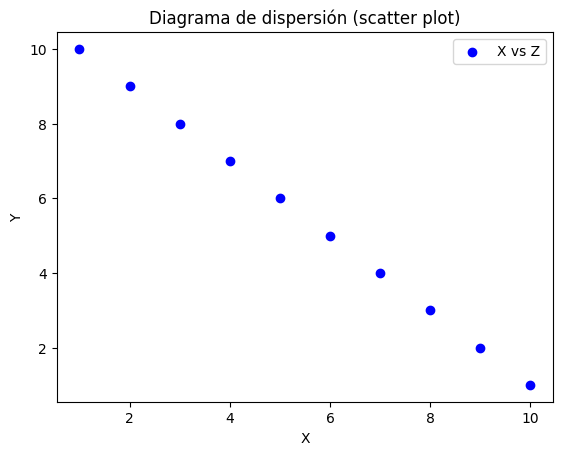

In [ ]:
import matplotlib.pyplot as plt
# Crear el gráfico de dispersión
#plt.scatter(data['X'], data['Y'], color='blue', label='X vs Y') # cambia X-Y-Z
plt.scatter(data['X'], data['Z'], color='blue', label='X vs Z')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Diagrama de dispersión (scatter plot)')
plt.legend()
plt.show()

#Correlación de Spearman

Usando SCIPY

In [ ]:
from scipy.stats import spearmanr

X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y = [10, 9, 2, 3, 4, 5, 6, 7, 8, 1]

# Correlación de Spearman
rho, p_value = spearmanr(X, Y)
print("Coeficiente de correlación de Spearman:", rho)

Coeficiente de correlación de Spearman: -0.32121212121212117


Usando NUMPY

In [ ]:
import numpy as np

# Datos
X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Y = [10, 9, 2, 3, 4, 5, 6, 7, 8, 1]

# Calcular los rangos
rank_X = np.argsort(np.argsort(X)) + 1
rank_Y = np.argsort(np.argsort(Y)) + 1

# Calcular las diferencias de rangos
d = rank_X - rank_Y

# Aplicar la fórmula de Spearman
n = len(X)
rho = 1 - (6 * np.sum(d**2)) / (n * (n**2 - 1))

print(f"Correlación de Spearman (calculada manualmente) entre X e Y: {rho}")


Correlación de Spearman (calculada manualmente) entre X e Y: -0.3212121212121213


Usando PANDAS

In [ ]:
import pandas as pd

# Crear un DataFrame con 3 columnas de ejemplo
data = pd.DataFrame({
    'X': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Y': [10, 9, 2, 3, 4, 5, 6, 7, 8, 1]
})

# Calcular la matriz de correlación de Spearman
correlation_matrix = data.corr(method='spearman')

# Mostrar la matriz de correlación
print("Matriz de correlación de Spearman:")
print(correlation_matrix)

# Mostrar la correlación específica entre X e Y
correlation_xy = correlation_matrix.loc['X', 'Y']
print(f"Correlación de Spearman entre X e Y: {correlation_xy}")


Matriz de correlación de Spearman:
          X         Y
X  1.000000 -0.321212
Y -0.321212  1.000000
Correlación de Spearman entre X e Y: -0.3212121212121212


#Correlación de Cramer

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

# Tabla de contingencia
data = pd.DataFrame({
    'Genero': ['Hombre', 'Hombre', 'Hombre', 'Mujer', 'Mujer', 'Mujer', 'Hombre', 'Mujer'],
    'Preferencia': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B']
})
contingency_table = pd.crosstab(data['Genero'], data['Preferencia'])

# Prueba chi-cuadrado
chi2, p, dof, expected = chi2_contingency(contingency_table)

# V de Cramér
n = contingency_table.sum().sum()
V = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print("V de Cramér:", V)

V de Cramér: 0.28867513459481287


Visualizando la tabla de contingencia

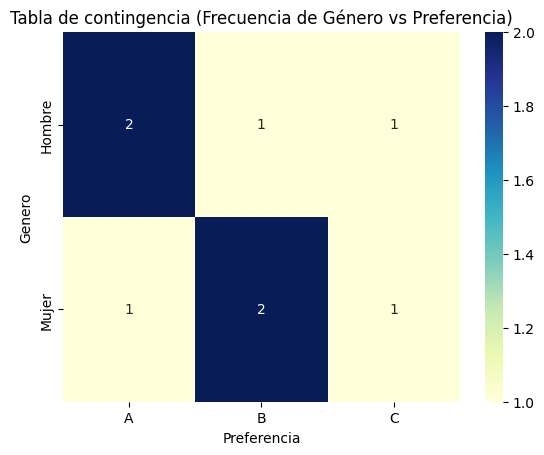

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Crear una tabla de contingencia
df = pd.DataFrame({
    'Genero': ['Hombre', 'Hombre', 'Hombre', 'Mujer', 'Mujer', 'Mujer', 'Hombre', 'Mujer'],
    'Preferencia': ['A', 'B', 'C', 'A', 'B', 'C', 'A', 'B']
})

contingency_table = pd.crosstab(df['Genero'], df['Preferencia'])

# Visualizar la tabla de contingencia como heatmap
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Tabla de contingencia (Frecuencia de Género vs Preferencia)")
plt.show()
